In [69]:
import numpy as np # Linear Regression
import pandas as pd # Dataset Handling
import math # Mathematical Operations

# Graphic Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Data Scaling

# Model libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


In [71]:
df = pd.read_csv('Downloads/Air_Quality.csv')
df.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-01-01 00:00:00+00:00,Brasilia,325.0,21.1,2.5,35.0,15.4,15.6,20.483337
1,2025-01-01 01:00:00+00:00,Brasilia,369.0,20.8,2.7,35.0,15.1,15.3,20.425000
2,2025-01-01 02:00:00+00:00,Brasilia,419.0,20.4,3.0,34.0,15.6,15.8,20.333332
3,2025-01-01 03:00:00+00:00,Brasilia,451.0,20.5,3.1,33.0,16.4,16.6,20.258335
4,2025-01-01 04:00:00+00:00,Brasilia,458.0,22.1,3.0,29.0,17.7,17.8,20.316668


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52560 non-null  object 
 1   City    52560 non-null  object 
 2   CO      52560 non-null  float64
 3   NO2     52560 non-null  float64
 4   SO2     52560 non-null  float64
 5   O3      52560 non-null  float64
 6   PM2.5   52560 non-null  float64
 7   PM10    52560 non-null  float64
 8   AQI     52560 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.6+ MB


In [75]:
df.isnull().sum()

Date     0
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
AQI      0
dtype: int64

In [77]:
df.duplicated().sum()

0

In [79]:
df['City'].unique()

array(['Brasilia', 'Cairo', 'Dubai', 'London', 'New York', 'Sydney'],
      dtype=object)

In [81]:
df.describe(include='all')

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
count,52560,52560,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
unique,8760,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-01-01 00:00:00+00:00,Brasilia,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6,8760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,245.269711,24.129863,15.485135,64.416267,17.246579,28.553288,41.236672
std,NaN,NaN,146.926588,19.323853,24.794611,35.054135,15.429194,36.877058,22.740643
min,NaN,NaN,52.000000,0.000000,0.300000,0.000000,0.000000,0.000000,7.600000
25%,NaN,NaN,155.000000,9.400000,1.900000,41.000000,5.800000,7.600000,23.600002
50%,NaN,NaN,206.000000,18.900000,5.200000,60.000000,11.900000,14.400000,33.475001
75%,NaN,NaN,288.000000,33.700000,20.400000,84.000000,23.500000,33.900000,59.949994


In [83]:
for col in df.columns:
    print(f'{col} has {df[col].isna().sum()} empty values') 

Date has 0 empty values
City has 0 empty values
CO has 0 empty values
NO2 has 0 empty values
SO2 has 0 empty values
O3 has 0 empty values
PM2.5 has 0 empty values
PM10 has 0 empty values
AQI has 0 empty values


# Data Visualization

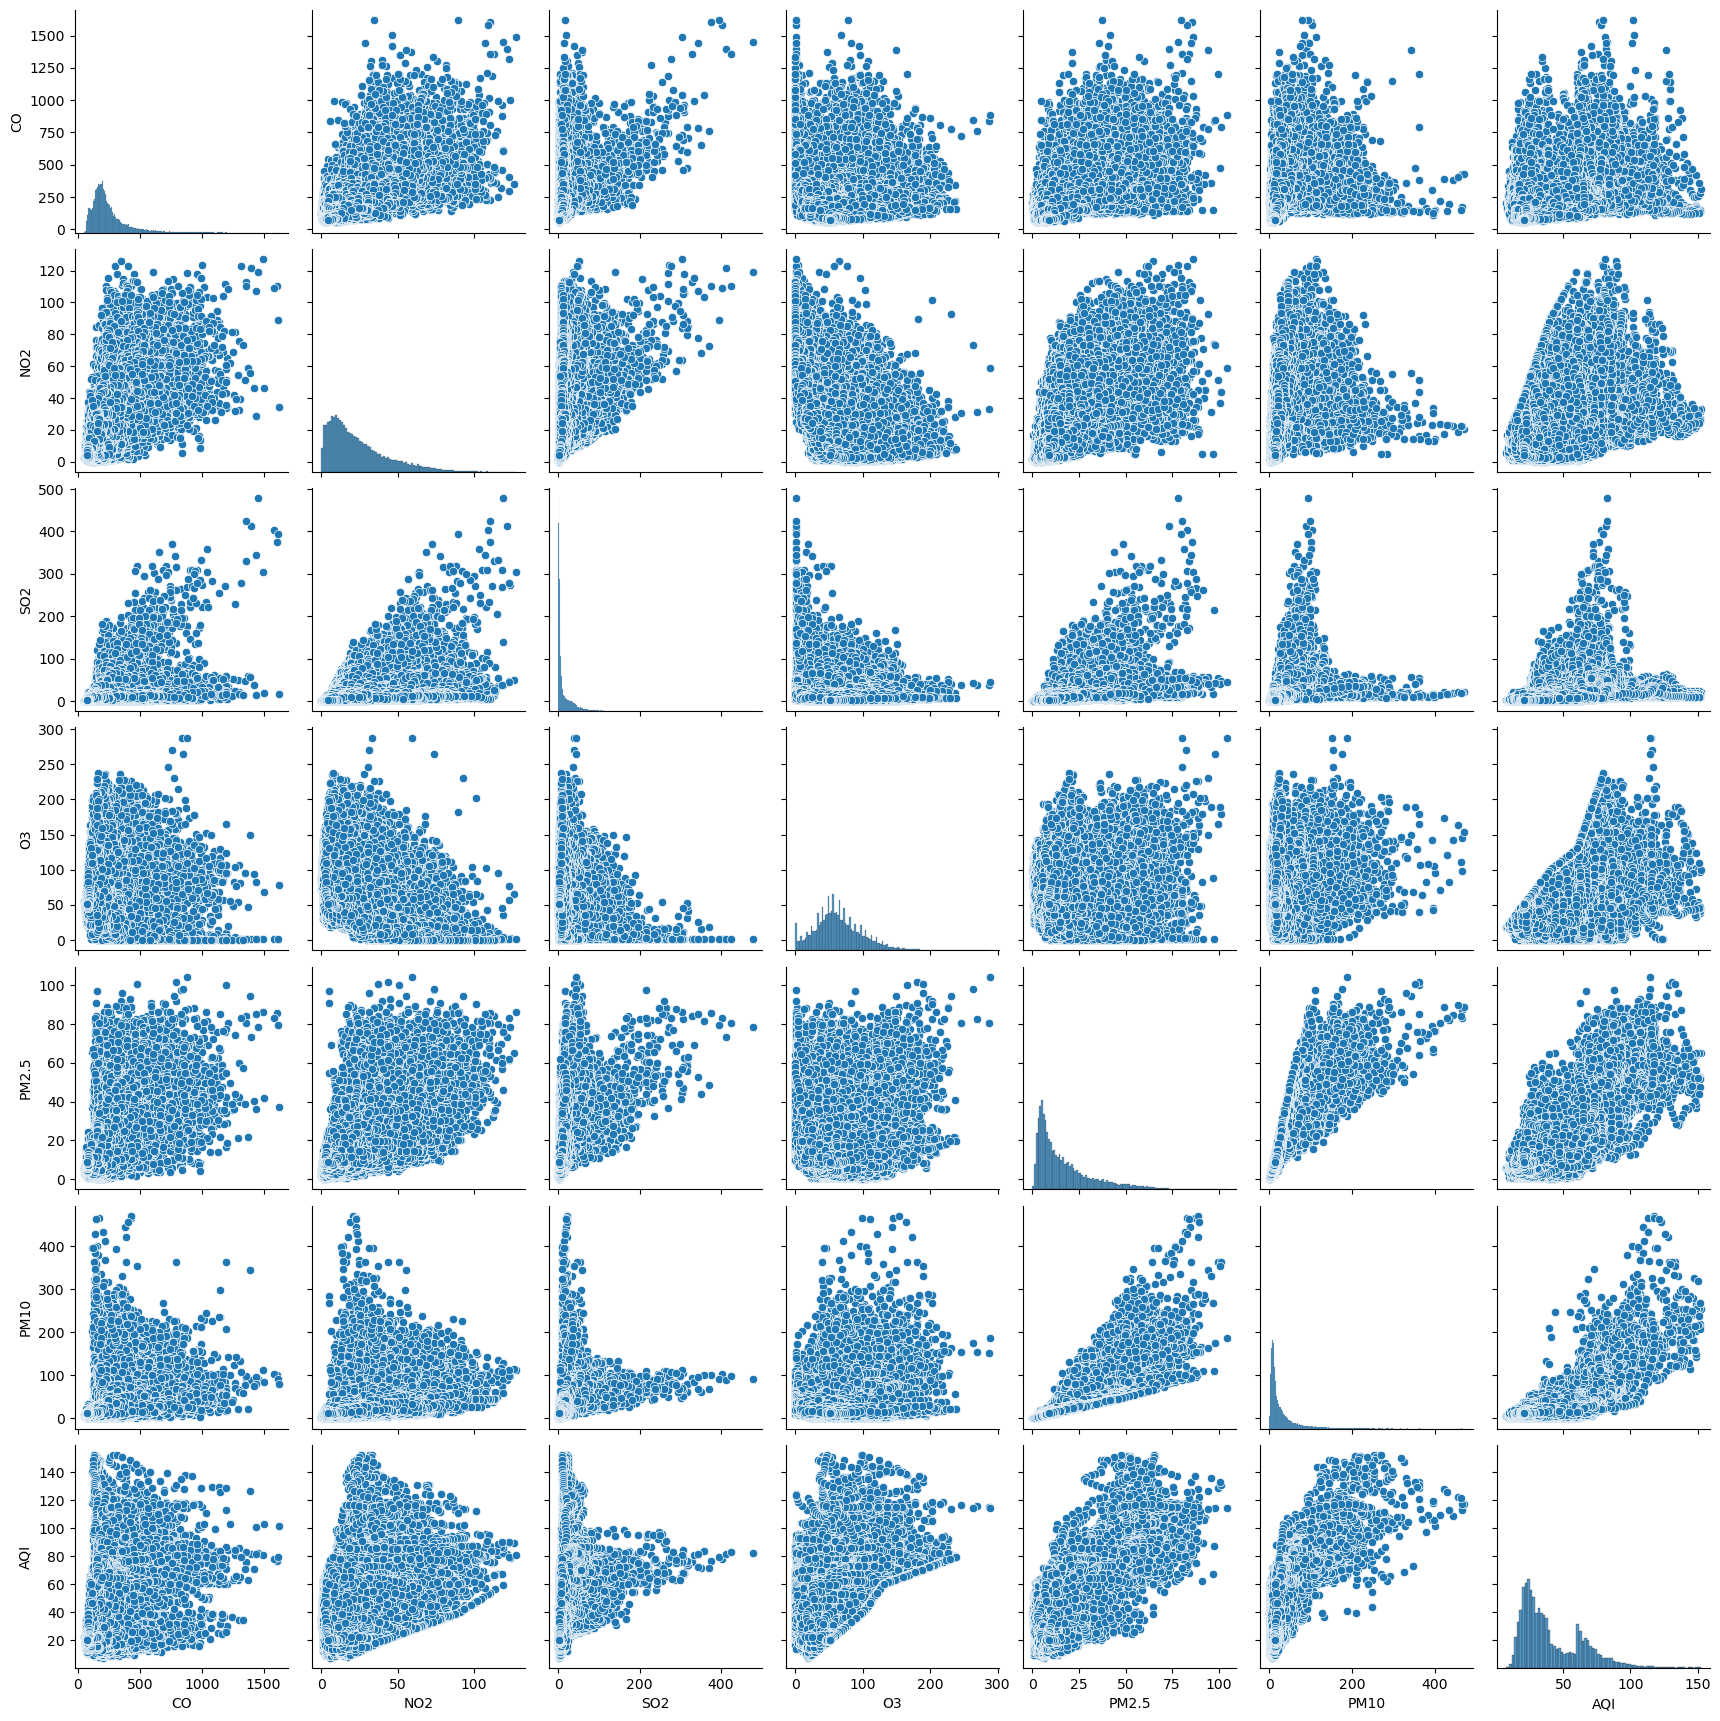

In [86]:
# Pair Plot
sns.pairplot(df)
plt.show()

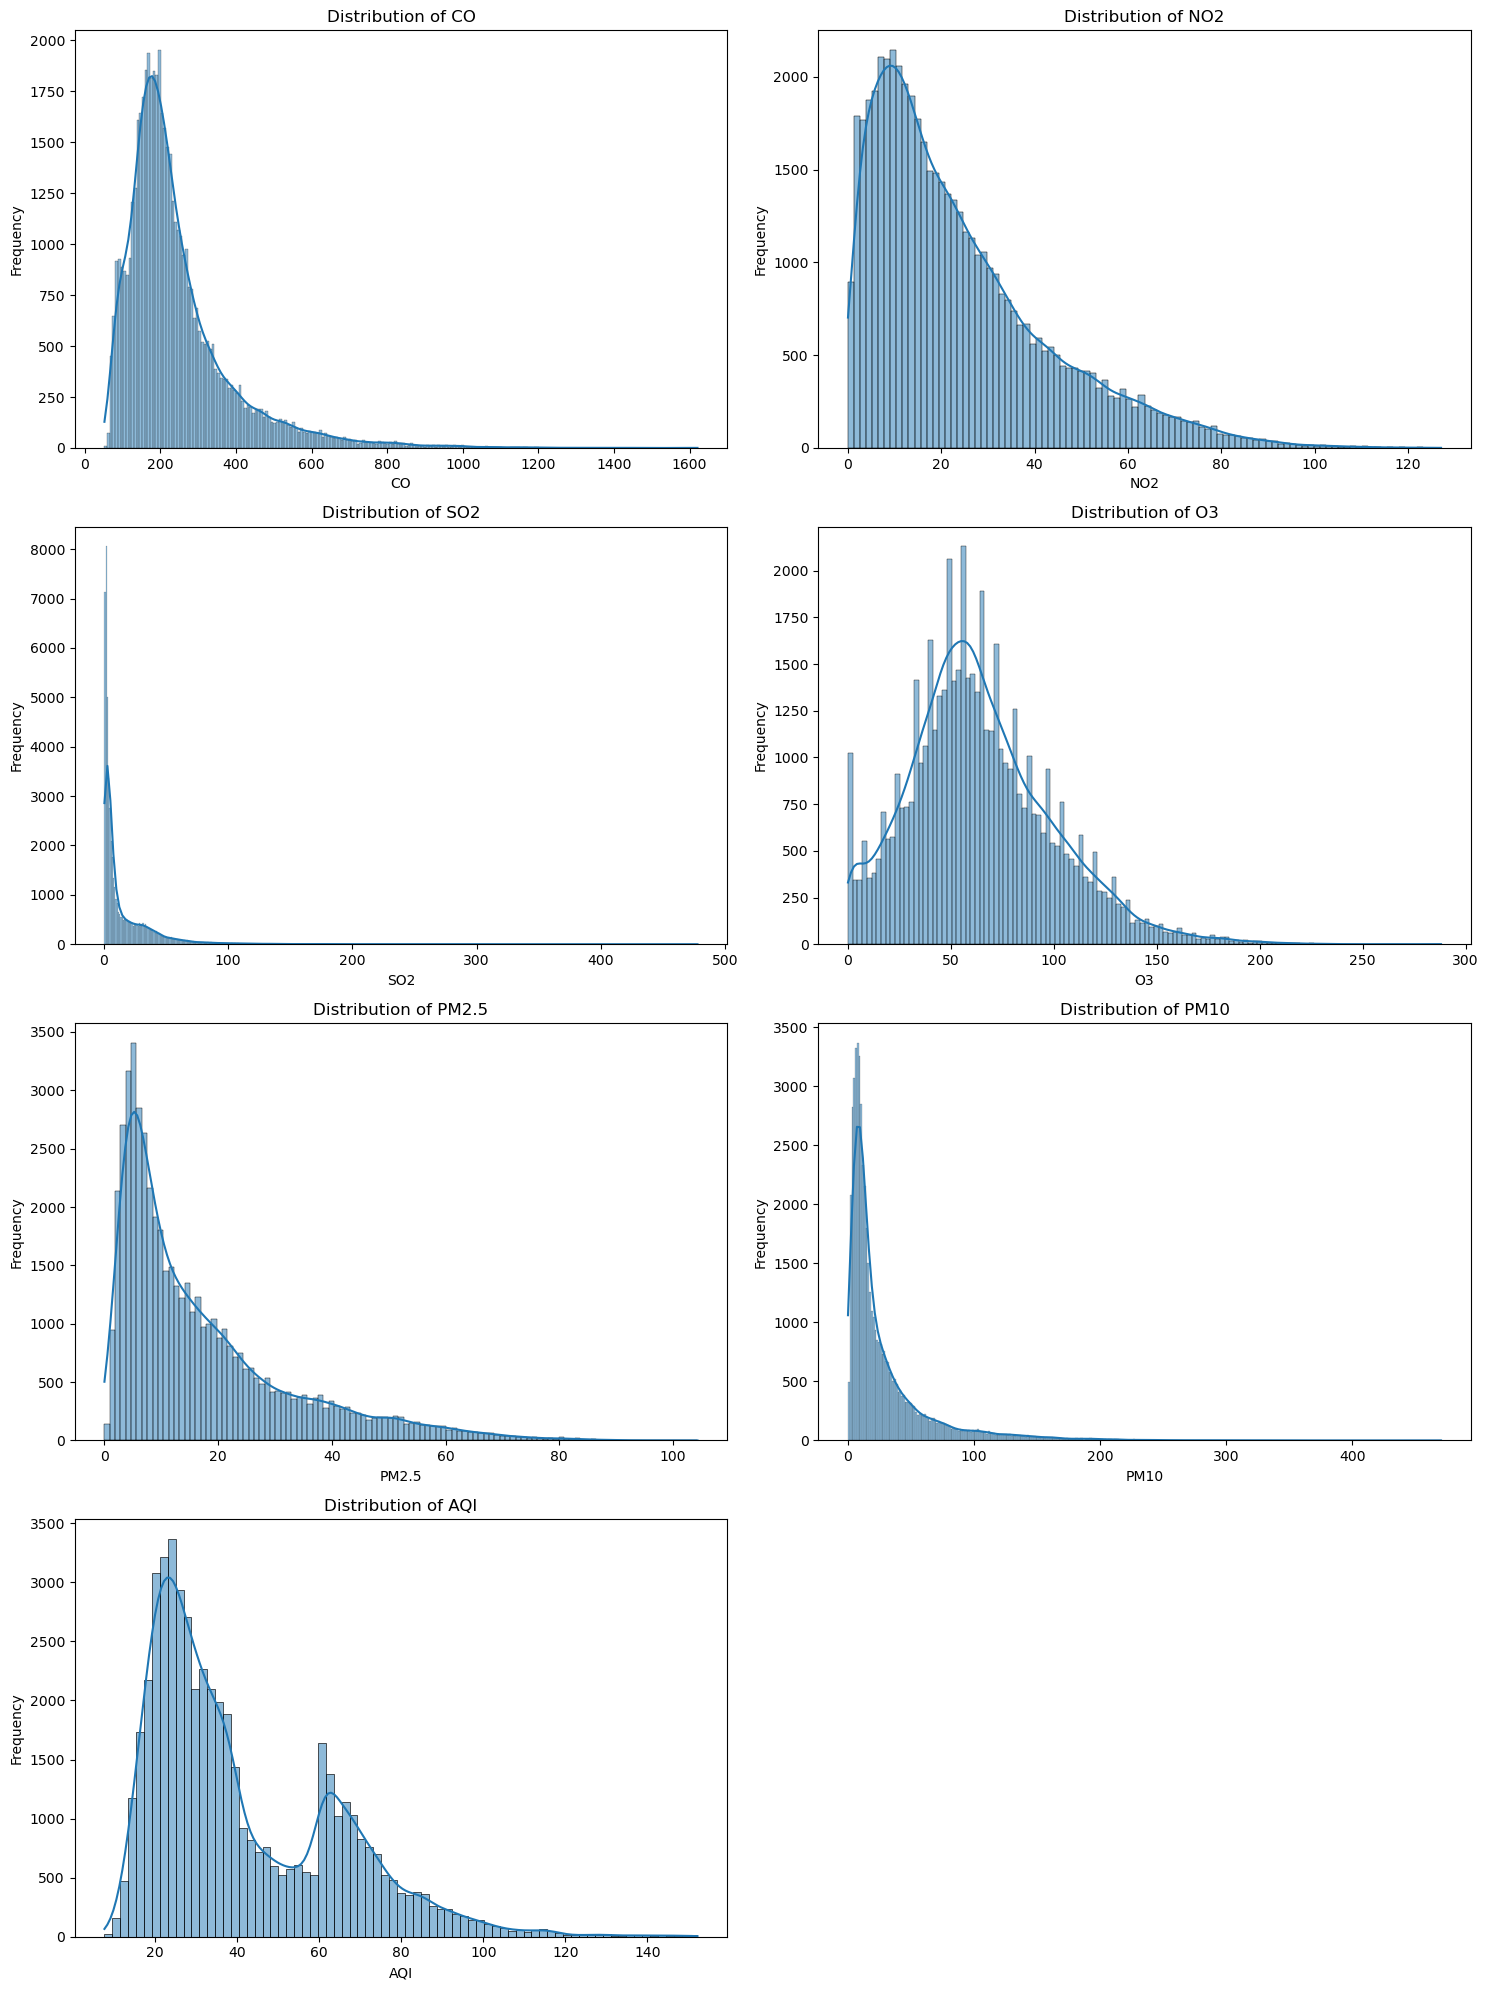

In [87]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

n_cols = 2
n_rows = math.ceil(len(numeric_cols)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

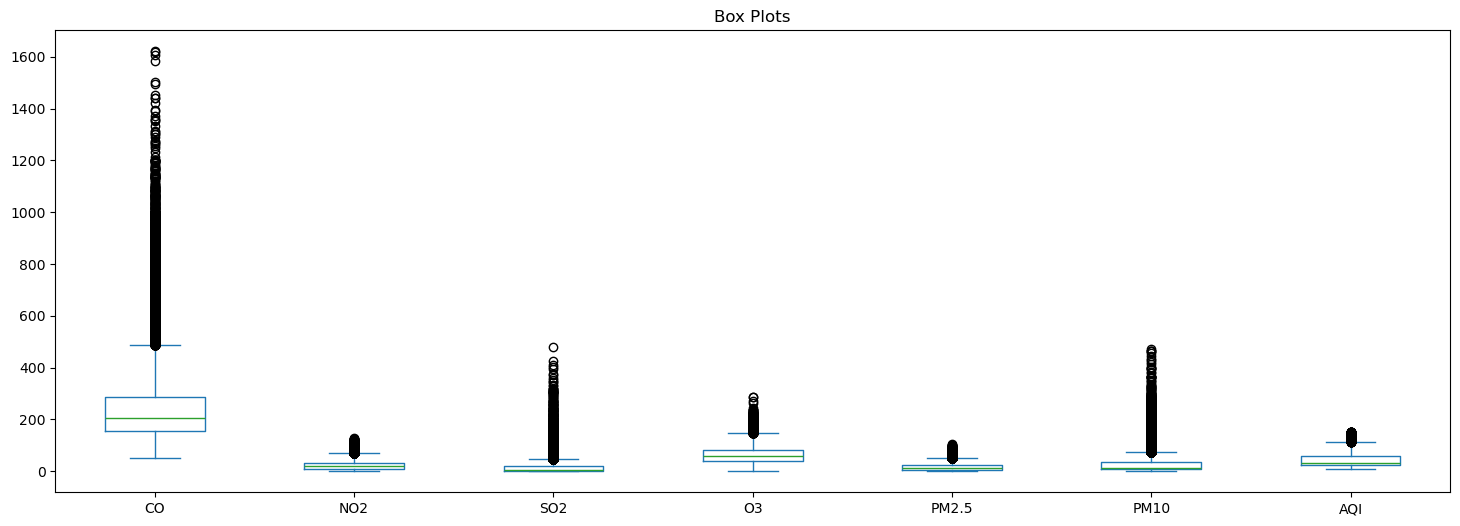

In [90]:
# Box Plot
df.plot(kind='box', figsize=(18,6))
plt.title('Box Plots')
plt.show()

In [92]:
df['numeric_cols'].skew()

KeyError: 'numeric_cols'

In [94]:
# Dropping columns
df.drop('Date', inplace=True, axis=1)


In [96]:
df.drop('City', inplace=True, axis=1)

In [98]:
# Data Splitting
X = df.drop('AQI', axis=1)
y = df['AQI']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [104]:
model = LinearRegression()

In [106]:
# Train the model on training data
model.fit(X_train, y_train)

LinearRegression()

In [108]:
y_pred=model.predict(X_test)

# Evaluate model performance

In [111]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [113]:
print("Model Performance Metrics:")
print(f"MAE  : {mae}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2}")

Model Performance Metrics:
MAE  : 7.350005892909505
RMSE : 10.204616099622577
R²   : 0.79815764548514
